In [6]:
import stixdcpy
import pkgutil

In [9]:
for m in pkgutil.iter_modules(stixdcpy.__path__):
    print(m.name)

algorithms
auxiliary
cfl
continuous_spectrogram
detector_view
energylut
housekeeping
imgspec
instrument
io
logger
net
quicklook
science
spectrogram
stix_map
time_util
transmission
utils


In [1]:

import stixdcpy.spectrogram
help(stixdcpy.spectrogram)


Help on module stixdcpy.spectrogram in stixdcpy:

NAME
    stixdcpy.spectrogram

CLASSES
    builtins.object
        Spectrogram
    
    class Spectrogram(builtins.object)
     |  Spectrogram(start_utc: str, end_utc: str, data: dict)
     |  
     |  Spectrogram object constructed using json data fetched  from STIX data  center
     |  
     |  Methods defined here:
     |  
     |  __init__(self, start_utc: str, end_utc: str, data: dict)
     |      Initialize self.  See help(type(self)) for accurate signature.
     |  
     |  peek(self, plot_type='spec', ax=None)
     |      Create quick-look plots for the loaded spectrogram data
     |      Parameters
     |      ----------
     |      ax: plt.axes
     |          axes to be plotted
     |      plot_type: str
     |          plot type, can be 'spec' to plot spectrogram or 'lc' to plot time series
     |  
     |  plot(self, energy_bins=None, min_time_bins=None, ax=None)
     |  
     |  --------------------------------------------

In [7]:
# Goal:
# Download STIX quick-look light curves around the flare
# SOL2021-09-21T09:46:22

from stixdcpy.quicklook import LightCurves

start_time = "2021-09-21T09:40:00"
end_time   = "2021-09-21T09:50:00"

lc = LightCurves.from_sdc(start_time, end_time)

<Axes: xlabel='UTC (4 sec time bins)', ylabel='Counts'>

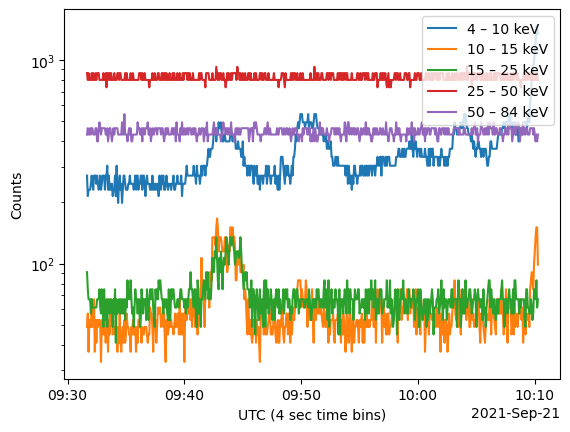

In [8]:
lc.peek()

In [16]:
# Structure of the returned object

type(lc)

stixdcpy.quicklook.LightCurves

In [17]:
data = lc.get_data()

type(data)

stixdcpy.net.ResponseDict

In [18]:
data.keys()

dict_keys(['cqllc', 'rcr', 'triggers', 'energy_bins', 'num', 'start_unix', 'start_utc', 'end_unix', 'end_utc', 'light_time_diff', 'solo_to_earth_light_time', 'is_light_time_corrected', 'delta_time', 'counts'])

In [19]:
# Goal:
# Inspect STIX energy bins and identify the channels
# corresponding to the bands used in the paper.

energy_bins = data["energy_bins"]

print(type(energy_bins))
print(energy_bins)

<class 'dict'>
{'names': ['4 – 10 keV', '10 – 15 keV', '15 – 25 keV', '25 – 50 keV', '50 – 84 keV'], 'sci_bin_edges': [[1, 7], [7, 12], [12, 17], [17, 23], [23, 28]]}


In [1]:
from stixdcpy.net import Request

flares = Request.fetch_flare_list(
    "2021-09-20T00:00:00",
    "2021-09-25T23:59:59"
)

type(flares)

stixdcpy.net.ResponseList

In [5]:
flare = flares[0]

flare.keys()

dict_keys(['flare_id', 'duration', 'att_in', 'peak_UTC', 'LC0_BKG', '_id', 'GOES_class', 'GOES_flux', 'goes_estimated_min_class', 'goes_estimated_max_class', 'goes_estimated_mean_class', 'goes_estimated_min_flux', 'goes_estimated_max_flux', 'goes_estimated_mean_flux', 'CFL_X_arcsec', 'CFL_Y_arcsec', 'start_UTC', 'end_UTC', 'LC0_PEAK_COUNTS_4S', 'LC0_BKG_COUNTS_4S', 'LC1_PEAK_COUNTS_4S', 'LC1_BKG_COUNTS_4S', 'LC2_PEAK_COUNTS_4S', 'LC2_BKG_COUNTS_4S', 'LC3_PEAK_COUNTS_4S', 'LC3_BKG_COUNTS_4S', 'LC4_PEAK_COUNTS_4S', 'LC4_BKG_COUNTS_4S'])

In [9]:
flares[0]

{'flare_id': '2109252306',
 'duration': 1412,
 'att_in': False,
 'peak_UTC': '2021-09-25T23:06:40.433',
 'LC0_BKG': 242.00761193876053,
 '_id': 3424,
 'GOES_class': 'B5.0',
 'GOES_flux': 5.004426952837093e-07,
 'goes_estimated_min_class': 'B5',
 'goes_estimated_max_class': 'B10',
 'goes_estimated_mean_class': 'B7',
 'goes_estimated_min_flux': None,
 'goes_estimated_max_flux': None,
 'goes_estimated_mean_flux': None,
 'CFL_X_arcsec': None,
 'CFL_Y_arcsec': None,
 'start_UTC': '2021-09-25T23:03:12.433',
 'end_UTC': '2021-09-25T23:26:44.435',
 'LC0_PEAK_COUNTS_4S': 1727,
 'LC0_BKG_COUNTS_4S': 247.0,
 'LC1_PEAK_COUNTS_4S': 303,
 'LC1_BKG_COUNTS_4S': 49.0,
 'LC2_PEAK_COUNTS_4S': 183,
 'LC2_BKG_COUNTS_4S': 67.0,
 'LC3_PEAK_COUNTS_4S': 863,
 'LC3_BKG_COUNTS_4S': 799.0,
 'LC4_PEAK_COUNTS_4S': 495,
 'LC4_BKG_COUNTS_4S': 431.0}

In [1]:
from stixdcpy.net import FitsQuery as fq

spec_res = fq.query(
    '2021-09-20T00:00:00',
    '2021-09-25T23:59:59',
    product_type='xray-spec'
)
df = spec_res.to_pandas()
print(f"Spectrogram files available: {len(df)}")
df

Spectrogram files available: 230


,url,observation_time_range,file_id,unique_id,product_type,product_group,level,detector_mask,pixel_mask,energy_range_keV,eunit,time_bin,duration
0,http://datacenter.stix.i4ds.net/download/fits/...,"[2021-09-22T17:37:51.757, 2021-09-22T19:01:57....",16263,2109220119,xray-spec,science,L1A,0xFFFFFCFF,0xFFF,"[4.0, 28.0]",1,0.5,5056
1,http://datacenter.stix.i4ds.net/download/fits/...,"[2021-09-22T19:15:17.167, 2021-09-22T20:05:13....",16264,2109220120,xray-spec,science,L1A,0xFFFFFCFF,0xFFF,"[4.0, 18.0]",1,0.5,3003
2,http://datacenter.stix.i4ds.net/download/fits/...,"[2021-09-22T22:27:11.487, 2021-09-22T22:43:32....",16265,2109220121,xray-spec,science,L1A,0xFFFFFCFF,0xFFF,"[4.0, 18.0]",1,0.5,985
3,http://datacenter.stix.i4ds.net/download/fits/...,"[2021-09-22T17:37:51.757, 2021-09-22T19:01:57....",16271,2109220119,xray-spec,science,L1A,0xFFFFFCFF,0xFFF,"[4.0, 28.0]",1,0.5,5056
4,http://datacenter.stix.i4ds.net/download/fits/...,"[2021-09-22T19:15:17.167, 2021-09-22T20:05:13....",16272,2109220120,xray-spec,science,L1A,0xFFFFFCFF,0xFFF,"[4.0, 18.0]",1,0.5,3003
...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,http://datacenter.stix.i4ds.net/download/fits/...,"[2021-09-25T21:01:46.220, 2021-09-25T22:22:13....",423029,2109250033,xray-spec,science,L1,0xFFFFFCFF,0xFFF,"[4.0, 28.0]",1,0.5,4840
226,http://datacenter.stix.i4ds.net/download/fits/...,"[2021-09-25T22:54:53.532, 2021-09-26T00:51:30....",423030,2109250034,xray-spec,science,L1,0xFFFFFCFF,0xFFF,"[4.0, 28.0]",1,0.5,7008
227,http://datacenter.stix.i4ds.net/download/fits/...,"[2021-09-20T18:42:40.193, 2021-09-20T20:38:05....",423045,2109200035,xray-spec,science,L1,0xFFFFFCFF,0xFFF,"[4.0, 28.0]",1,0.5,6928
228,http://datacenter.stix.i4ds.net/download/fits/...,"[2021-09-20T20:29:25.582, 2021-09-20T22:22:28....",423046,2109200036,xray-spec,science,L1,0xFFFFFCFF,0xFFF,"[4.0, 50.0]",1,0.5,6780


In [4]:
from stixdcpy import spectrogram as cspec

# Use one of our actual flare times — row 50
spec = cspec.Spectrogram.from_sdc(
    '2021-09-24T19:33:00',
    '2021-09-24T19:57:00'
)
print(type(spec))
print(dir(spec))

IndexError: list index out of range

In [5]:
import pandas as pd

# Parse the observation time ranges properly
df["obs_start"] = df["observation_time_range"].apply(lambda x: pd.Timestamp(x[0]))
df["obs_end"]   = df["observation_time_range"].apply(lambda x: pd.Timestamp(x[1]))

# Drop duplicates — keep L1 over L1A where both exist
df_clean = df.sort_values("level").drop_duplicates(subset="unique_id", keep="last")

print(f"Unique spectrogram files: {len(df_clean)}")
print(f"\nDate coverage:")
print(f"  Earliest: {df_clean['obs_start'].min()}")
print(f"  Latest:   {df_clean['obs_end'].max()}")
print(f"\nFiles by date:")
print(df_clean.groupby(df_clean['obs_start'].dt.date).size())
print(f"\nEnergy ranges available:")
print(df_clean['energy_range_keV'].value_counts())

Unique spectrogram files: 56

Date coverage:
  Earliest: 2021-09-20 18:42:40.093000
  Latest:   2021-09-26 00:51:29.932000

Files by date:
obs_start
2021-09-20     3
2021-09-21    10
2021-09-22    13
2021-09-23    10
2021-09-24     9
2021-09-25    11
dtype: int64

Energy ranges available:
energy_range_keV
[4.0, 28.0]        40
[4.0, 50.0]         7
[4.0, 18.0]         7
[4.0, 40.0]         1
[4.0, Infinity]     1
Name: count, dtype: int64


In [12]:
# Load our flare catalog and check which flares fall inside a spectrogram window
flare_df = pd.read_csv("D:/Study/Research/Extreme Thermal and Non-Thermal Solar Flares/data/processed/stix_flare_catalog_sep20_25_2021.csv")
flare_df["flare_id"]  = flare_df["flare_id"].astype(str)
flare_df["start_UTC"] = pd.to_datetime(flare_df["start_UTC"])
flare_df["end_UTC"]   = pd.to_datetime(flare_df["end_UTC"])

def find_covering_file(flare_start, flare_end, spec_df):
    """Find spectrogram file(s) that fully cover a flare window."""
    mask = (spec_df["obs_start"] <= flare_start) & (spec_df["obs_end"] >= flare_end)
    return spec_df[mask]

covered = []
for _, flare in flare_df.iterrows():
    match = find_covering_file(flare["start_UTC"], flare["end_UTC"], df_clean)
    covered.append(len(match) > 0)

flare_df["has_spectrogram"] = covered
print(f"Flares with spectrogram coverage: {sum(covered)} / {len(flare_df)}")
print(f"Flares WITHOUT coverage:          {len(flare_df) - sum(covered)}")

Flares with spectrogram coverage: 175 / 215
Flares WITHOUT coverage:          40


In [13]:
uncovered = flare_df[~flare_df["has_spectrogram"]]
print(uncovered[["flare_id", "start_UTC", "end_UTC"]].to_string())

       flare_id               start_UTC                 end_UTC
4    2109252058 2021-09-25 20:54:48.420 2021-09-25 21:01:56.421
11   2109251700 2021-09-25 16:58:24.396 2021-09-25 17:01:20.396
15   2109251542 2021-09-25 15:41:56.388 2021-09-25 15:43:16.388
16   2109251412 2021-09-25 14:11:32.378 2021-09-25 14:17:44.379
17   2109251336 2021-09-25 13:34:32.375 2021-09-25 13:41:08.375
29   2109250425 2021-09-25 04:24:36.318 2021-09-25 04:25:48.318
34   2109250250 2021-09-25 02:49:20.309 2021-09-25 02:50:32.309
40   2109242353 2021-09-24 23:50:56.290 2021-09-24 23:55:36.291
46   2109242146 2021-09-24 21:43:56.277 2021-09-24 21:47:04.278
50   2109241944 2021-09-24 19:43:44.265 2021-09-24 19:46:36.265
53   2109241736 2021-09-24 17:35:24.252 2021-09-24 17:37:20.252
56   2109241429 2021-09-24 14:28:12.233 2021-09-24 14:30:52.233
57   2109241332 2021-09-24 13:32:12.227 2021-09-24 13:32:56.227
58   2109241256 2021-09-24 12:53:36.223 2021-09-24 13:01:28.224
59   2109241208 2021-09-24 12:06:28.218 

In [14]:
covered_flares = flare_df[flare_df["has_spectrogram"]].copy()

# Exclude the two suspicious long-duration events
covered_flares = covered_flares[covered_flares["duration"] < 1800]

# Show a sample of clean covered flares
covered_flares[["flare_id","start_UTC","end_UTC","duration","GOES_class"]].iloc[10:20]

,flare_id,start_UTC,end_UTC,duration,GOES_class
12,2109251623,2021-09-25 16:22:00.395,2021-09-25 16:30:36.396,516,B2.2
13,2109251607,2021-09-25 16:04:40.394,2021-09-25 16:11:48.394,428,B2.2
14,2109251553,2021-09-25 15:52:12.389,2021-09-25 15:54:20.389,128,B1.8
18,2109251240,2021-09-25 12:36:32.369,2021-09-25 12:47:48.370,676,B5.2
20,2109251125,2021-09-25 11:08:28.360,2021-09-25 11:35:52.363,1644,C1.1
21,2109250950,2021-09-25 09:45:24.352,2021-09-25 09:51:48.353,384,B2.5
22,2109250942,2021-09-25 09:41:24.351,2021-09-25 09:44:12.352,168,B2.2
23,2109250916,2021-09-25 09:12:00.349,2021-09-25 09:19:04.350,424,B2.9
24,2109250856,2021-09-25 08:43:44.345,2021-09-25 09:08:20.349,1476,B3.3
25,2109250809,2021-09-25 07:48:04.339,2021-09-25 08:16:40.342,1716,B6.0


In [15]:
pad = pd.Timedelta(minutes=10)
flare_row = covered_flares[covered_flares["flare_id"] == "2109250916"].iloc[0]

spec = cspec.Spectrogram.from_sdc(
    (flare_row["start_UTC"] - pad).strftime("%Y-%m-%dT%H:%M:%S"),
    (flare_row["end_UTC"] + pad).strftime("%Y-%m-%dT%H:%M:%S"),
)
print(type(spec))
print(dir(spec))

<class 'stixdcpy.spectrogram.Spectrogram'>
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'data', 'end_utc', 'from_sdc', 'peek', 'plot', 'start_utc']


In [2]:
from stixdcpy import spectrogram as cspec
import pandas as pd

spec = cspec.Spectrogram.from_sdc(
    '2021-09-25T09:02:00',
    '2021-09-25T09:30:00'
)
print(type(spec))
print(spec.data.keys())

<class 'stixdcpy.spectrogram.Spectrogram'>
dict_keys(['datetime', 'time_bin', 'timedel', 'spectrogram', 'time_bins', 'triggers', 'rcr', 'elow', 'ehigh', 'dmask', 'pmask', 'energy_bins', 'energy_bin_names'])


In [5]:
import numpy as np

counts = spec.data['spectrogram']
dt = spec.data['datetime']

print("counts shape :", np.array(counts).shape)
print("cadence (s)  :", (dt[1] - dt[0]).total_seconds())
print("first time   :", dt[0])
print("last time    :", dt[-1])

counts shape : (17, 87)
cadence (s)  : 17.8
first time   : 2021-09-25 09:02:04.738000
last time    : 2021-09-25 09:29:19.038000


In [6]:
print("energy bin names:")
for i, name in enumerate(spec.data['energy_bin_names']):
    print(f"  [{i:2d}]  {name}")

energy bin names:
  [ 0]  4.0 – 5.0 keV
  [ 1]  5.0 – 6.0 keV
  [ 2]  6.0 – 7.0 keV
  [ 3]  7.0 – 8.0 keV
  [ 4]  8.0 – 9.0 keV
  [ 5]  9.0 – 10.0 keV
  [ 6]  10.0 – 11.0 keV
  [ 7]  11.0 – 12.0 keV
  [ 8]  12.0 – 13.0 keV
  [ 9]  13.0 – 14.0 keV
  [10]  14.0 – 15.0 keV
  [11]  15.0 – 16.0 keV
  [12]  16.0 – 18.0 keV
  [13]  18.0 – 20.0 keV
  [14]  20.0 – 22.0 keV
  [15]  22.0 – 25.0 keV
  [16]  25.0 – 28.0 keV
